In [1]:
import tensorflow as tf
gpu = tf.config.list_physical_devices("GPU")
print(gpu)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# !pip install pandas==1.5.3
# !pip install seaborn==0.12.2

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('dataset/pima-indians-diabetes.csv')
df.head()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
df['diabetes'].value_counts()

0    500
1    268
Name: diabetes, dtype: int64

In [11]:
df.describe()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [12]:
df.corr()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
pregnant,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plasma,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedigree,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


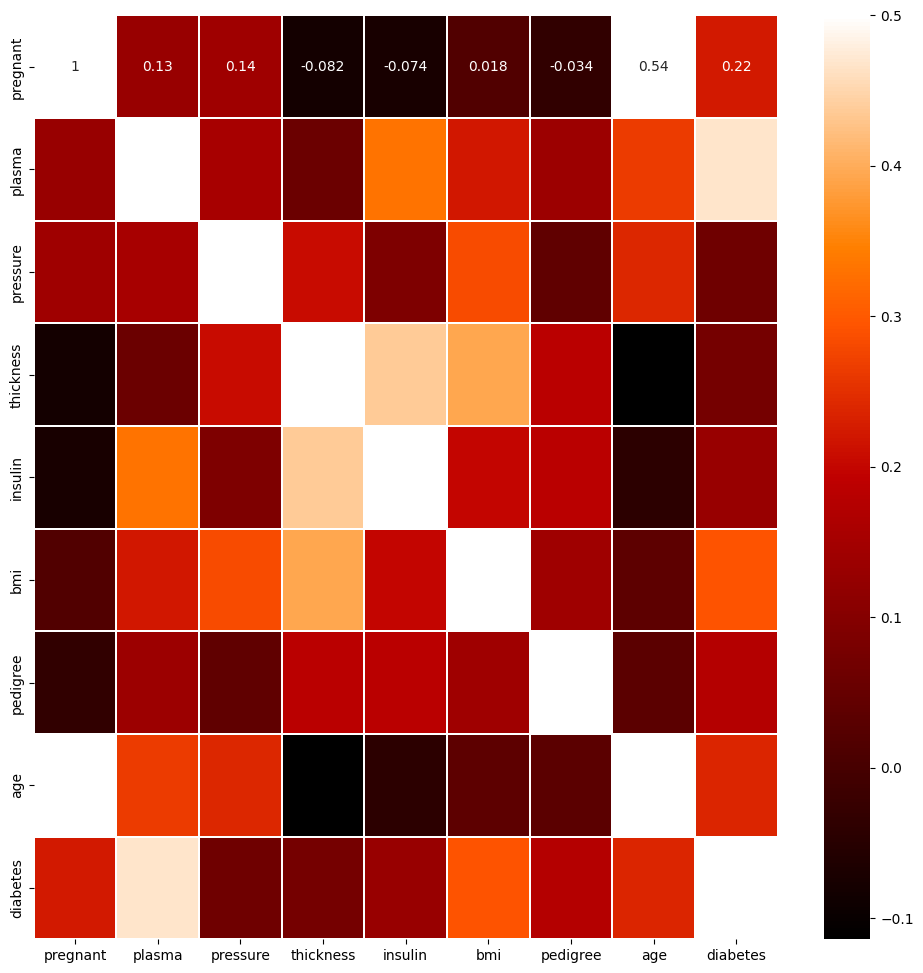

In [20]:
colormap = plt.cm.gist_heat
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(),linewidth=0.1,cmap=colormap,
           linecolor='white',vmax=0.5,annot=True)
plt.show()

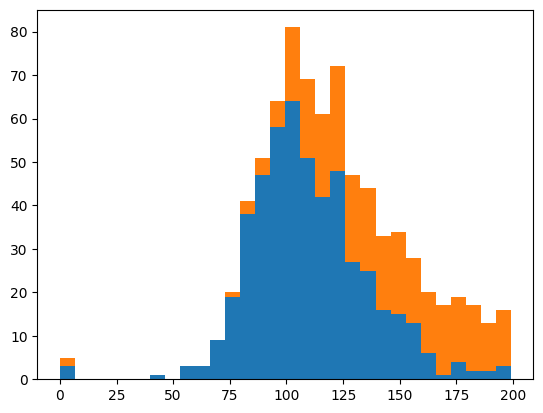

In [30]:
plt.hist(x=[df.plasma[df.diabetes==0],df.plasma[df.diabetes==1]],
        bins=30,histtype='barstacked',label=['normal','diabetes'])
plt.show()

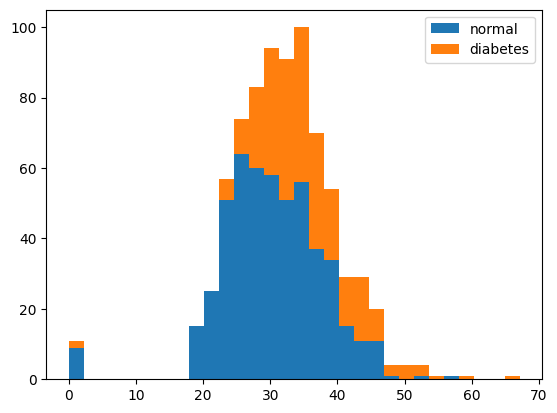

In [31]:
plt.hist(x=[df.bmi[df.diabetes==0],df.bmi[df.diabetes==1]],
        bins=30,histtype='barstacked',label=['normal','diabetes'])
plt.legend()

<h1>피마 인디언 부족 당뇨병 예측</h1>

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [60]:
x = df.iloc[:,0:8].values
y = df.iloc[:,8].values

In [61]:
# 모델 생성

model =Sequential()
model.add(Dense(12,input_shape=(8,),activation='relu',name='Dense01'))
model.add(Dense(8,activation='relu',name='Dense02'))
model.add(Dense(1,activation='sigmoid',name='Dense03'))
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Dense01 (Dense)             (None, 12)                108       
                                                                 
 Dense02 (Dense)             (None, 8)                 104       
                                                                 
 Dense03 (Dense)             (None, 1)                 9         
                                                                 
Total params: 221
Trainable params: 221
Non-trainable params: 0
_________________________________________________________________


In [62]:
# 모델 컴파일

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [63]:
history = model.fit(x, y, epochs=100, batch_size=5)

Epoch 1/100
154/154 [==============================] - 1s 5ms/step - loss: 14.0384 - accuracy: 0.5039
Epoch 2/100
154/154 [==============================] - 1s 5ms/step - loss: 1.8380 - accuracy: 0.6380
Epoch 3/100
154/154 [==============================] - 1s 6ms/step - loss: 1.3808 - accuracy: 0.6341
Epoch 4/100
154/154 [==============================] - 1s 4ms/step - loss: 1.1840 - accuracy: 0.6172
Epoch 5/100
154/154 [==============================] - 1s 4ms/step - loss: 1.0019 - accuracy: 0.6341
Epoch 6/100
154/154 [==============================] - 0s 3ms/step - loss: 0.8551 - accuracy: 0.6510
Epoch 7/100
154/154 [==============================] - 0s 3ms/step - loss: 0.7083 - accuracy: 0.6406
Epoch 8/100
154/154 [==============================] - 1s 3ms/step - loss: 0.6780 - accuracy: 0.6484
Epoch 9/100
154/154 [==============================] - 0s 3ms/step - loss: 0.6829 - accuracy: 0.6497
Epoch 10/100
154/154 [==============================] - 1s 3ms/step - loss: 0.6534 - accur

In [64]:
print("Accuracy : %4f" % (model.evaluate(x, y))[1])

24/24 [==============================] - 0s 2ms/step - loss: 0.4897 - accuracy: 0.7721
Accuracy : 0.772135


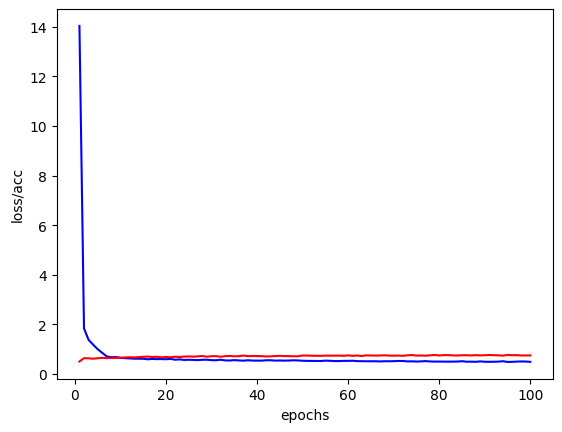

In [66]:
loss= history.history['loss']
acc = history.history['accuracy']
epochs = range(1,len(loss)+1)

plt.plot(epochs,loss,'b',label='Training Loss')
plt.plot(epochs, acc , 'r' , label='Accuracy')
plt.xlabel('epochs')
plt.ylabel('loss/acc')
plt.show()